In [1]:
import torch
import torch.nn as nn 
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


## **Model Architecture**

In [30]:

class CNN_model(nn.Module):
    def __init__(self, in_channel, num_classes):
        super().__init__()
        
        # Convolution blocks
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channel, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
            
            
        )
        
        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully connected classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),                  # [B, 128, 1, 1] -> [B, 128]
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.gap(x)  # global average pooling
        x = self.classifier(x)
        return x


## **Data Loaders**

In [2]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
import random
from collections import defaultdict

# Define standard transform for basic transformations
transform_standard = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def rotate_90s():
    return transforms.Lambda(lambda img: img.rotate(random.choice([90, 180, 270])))

# Define augmentation transforms
augmentation_transforms = [
    transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        rotate_90s(),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
        rotate_90s(),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        rotate_90s(),
        transforms.RandomAffine(degrees=10, translate=(0.01, 0.01), scale=(0.95, 1.05)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.CenterCrop((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        rotate_90s(),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
]


class SimpleDataset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        return self.transform(img), label


class BalancedAugmentedDataset(Dataset):
    """
    Smart dataset that applies augmentations only to underrepresented classes.
    Ensures all original samples are kept and augmentations are added strategically.
    """
    def __init__(self, dataset, indices, transform=None, target_samples_per_class=None):
        """
        Args:
            dataset: Original ImageFolder dataset
            indices: Indices for this split (train/val/test)
            transform: Transform to apply to original samples
            target_samples_per_class: Target number of samples per class (uses mean if None)
        """
        self.dataset = dataset
        self.base_transform = transform if transform else transform_standard
        
        # Group indices by class
        self.class_to_indices = defaultdict(list)
        for idx in indices:
            _, label = dataset[idx]
            self.class_to_indices[label].append(idx)
        
        # Calculate target samples per class (mean if not specified)
        if target_samples_per_class is None:
            samples_per_class = [len(idxs) for idxs in self.class_to_indices.values()]
            self.target_samples = int(sum(samples_per_class) / len(samples_per_class))
        else:
            self.target_samples = target_samples_per_class
        
        print(f"\nTarget samples per class: {self.target_samples}")
        
        # Build the augmented dataset structure
        self.samples = []  # List of (original_idx, aug_transform_idx, label)
        
        for label, original_indices in self.class_to_indices.items():
            num_original = len(original_indices)
            
            # Always add all original samples first (aug_transform_idx = -1 means no augmentation)
            for idx in original_indices:
                self.samples.append((idx, -1, label))
            
            # Calculate how many augmentations we need
            if num_original < self.target_samples:
                num_augmentations_needed = self.target_samples - num_original
                
                print(f"Class {label}: {num_original} original samples, "
                      f"adding {num_augmentations_needed} augmentations")
                
                # Cycle through original images and augmentation transforms
                aug_count = 0
                while aug_count < num_augmentations_needed:
                    for idx in original_indices:
                        if aug_count >= num_augmentations_needed:
                            break
                        
                        # Select augmentation transform (cycle through available transforms)
                        aug_transform_idx = aug_count % len(augmentation_transforms)
                        self.samples.append((idx, aug_transform_idx, label))
                        aug_count += 1
            else:
                print(f"Class {label}: {num_original} original samples (above target, no augmentation needed)")
        
        print(f"\nTotal dataset size: {len(self.samples)}")
        print(f"  - Original samples: {len(indices)}")
        print(f"  - Augmented samples: {len(self.samples) - len(indices)}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        original_idx, aug_transform_idx, label = self.samples[idx]
        img, _ = self.dataset[original_idx]
        
        # Apply augmentation if specified, otherwise use base transform
        if aug_transform_idx == -1:
            # Original sample with base transform
            return self.base_transform(img), label
        else:
            # Augmented sample
            return augmentation_transforms[aug_transform_idx](img), label

        

In [4]:
# Path to the RealWaste dataset
data_dir = "realwaste-main/RealWaste"  # Update if needed

# Load the original dataset without transforms (we'll apply them in the wrapper)
dataset = datasets.ImageFolder(root=data_dir, transform=None)

# Get dataset size
dataset_size = len(dataset)
num_classes = len(dataset.classes)

print(f"Original dataset size: {dataset_size}")
print(f"Class names: {dataset.classes}")


# Calculate split sizes (70% train, 15% validation, 15% test)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

# Create indices for the splits
indices = list(range(dataset_size))
random.seed(42)  # For reproducibility
random.shuffle(indices)

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

# Create base dataset splits
train_dataset = BalancedAugmentedDataset(
    dataset, 
    train_indices, 
    transform=transform_standard,
    target_samples_per_class=None  # Will use mean, or specify a number like 1000
)

val_dataset = SimpleDataset(dataset, val_indices, transform_standard)
test_dataset = SimpleDataset(dataset, test_indices, transform_standard)

# Augment only the training set (4 augmentations per image + original)


# Print split information
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Original dataset size: 4752
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']

Target samples per class: 369
Class 5: 349 original samples, adding 20 augmentations
Class 0: 332 original samples, adding 37 augmentations
Class 6: 637 original samples (above target, no augmentation needed)
Class 1: 273 original samples, adding 96 augmentations
Class 3: 544 original samples (above target, no augmentation needed)
Class 7: 234 original samples, adding 135 augmentations
Class 8: 315 original samples, adding 54 augmentations
Class 2: 291 original samples, adding 78 augmentations
Class 4: 351 original samples, adding 18 augmentations

Total dataset size: 3764
  - Original samples: 3326
  - Augmented samples: 438
Training samples: 3764
Validation samples: 712
Test samples: 714


Saving test dataset for later use

In [5]:
import os
import shutil

# Destination for saved test images (change if needed)
dest_root = "realwaste-main/test_dataset"
os.makedirs(dest_root, exist_ok=True)

copied = 0
for idx in test_indices:
    src_path, class_idx = dataset.samples[idx]   # ImageFolder stores (path, class_idx)
    class_name = dataset.classes[class_idx]
    dst_class_dir = os.path.join(dest_root, class_name)
    os.makedirs(dst_class_dir, exist_ok=True)

    base_name = os.path.basename(src_path)
    dst_path = os.path.join(dst_class_dir, base_name)

    # avoid overwrite
    if os.path.exists(dst_path):
        name, ext = os.path.splitext(base_name)
        dst_path = os.path.join(dst_class_dir, f"{name}_{idx}{ext}")

    shutil.copy2(src_path, dst_path)
    copied += 1

print(f"Saved {copied} test images to: {dest_root}")

# Create a zip archive next to the folder (result: e:\Projects\CNN\test_dataset.zip)
archive_base = os.path.join(os.path.dirname(dest_root), os.path.basename(dest_root))
archive_path = shutil.make_archive(archive_base, 'zip', root_dir=dest_root)
print(f"Created zip archive: {archive_path}")

Saved 714 test images to: realwaste-main/test_dataset
Created zip archive: d:\ENTC ACA\PR\EN3150-Assignment-03\realwaste-main\test_dataset.zip


In [6]:
def count_samples_per_class(dataset, num_classes):
    """Count the number of samples per class in a dataset"""
    class_counts = {i: 0 for i in range(num_classes)}
    
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        label_idx = label.item() if isinstance(label, torch.Tensor) else label
        class_counts[label_idx] += 1
    
    print("\n" + "="*50)
    print("Class distribution:")
    print("="*50)
    print(f"{'Class':<10} {'Count':<10} {'Percentage':<10}")
    print("-" * 50)
    
    total_samples = len(dataset)
    for class_idx, count in class_counts.items():
        percentage = (count / total_samples) * 100
        print(f"{class_idx:<10} {count:<10} {percentage:.2f}%")
    
    min_count = min(class_counts.values())
    max_count = max(class_counts.values())
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
    print("-" * 50)
    print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")
    print("="*50)
    
    return class_counts

# Analyze the balanced training dataset
train_class_counts = count_samples_per_class(train_dataset, len(dataset.classes))



Class distribution:
Class      Count      Percentage
--------------------------------------------------
0          369        9.80%
1          369        9.80%
2          369        9.80%
3          544        14.45%
4          369        9.80%
5          369        9.80%
6          637        16.92%
7          369        9.80%
8          369        9.80%
--------------------------------------------------
Imbalance ratio (max/min): 1.73


Creating the Dataloaders

In [29]:
# Create data loaders
batch_size = 32  # Smaller batch size for larger images
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


Visualization of a batch

Checking training data...
Batch shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])


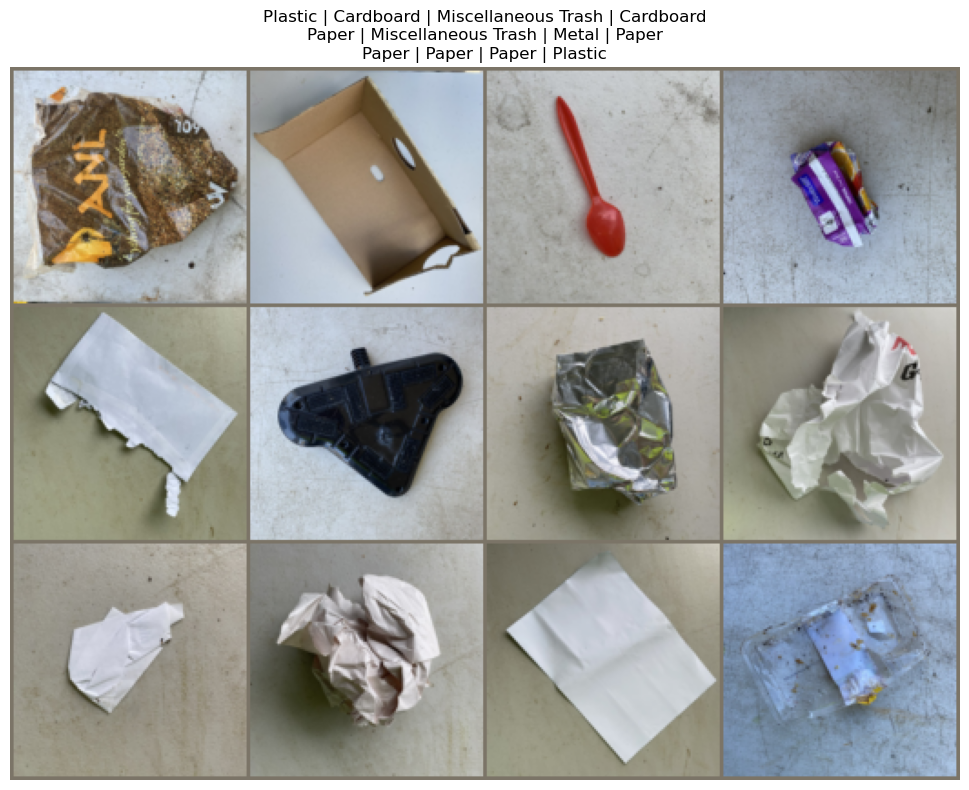

Has NaN: False
Has Inf: False
Min value: -2.1007792949676514
Max value: 2.6051416397094727

Checking validation data...
Batch shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])


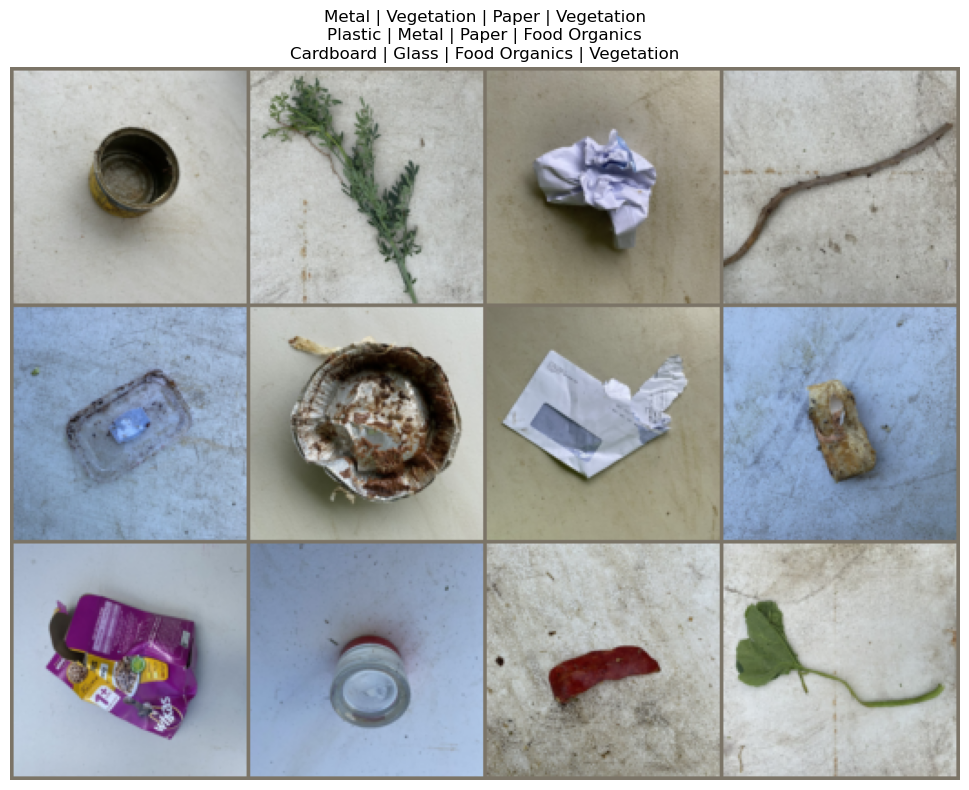

Has NaN: False
Has Inf: False
Min value: -2.1007792949676514
Max value: 2.6051416397094727


True

In [49]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import numpy as np

def show_batch(dataloader, classes, num_images=12):
    """
    Display a batch of images with their labels from a dataloader
    
    Args:
        dataloader: PyTorch dataloader to get images from
        classes: List of class names
        num_images: Maximum number of images to display
    """
    # Get a batch of training data
    images, labels = next(iter(dataloader))
    print(f"Batch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    
    # Convert images back to a displayable format
    images = images[:num_images]  # Take only the first num_images
    labels = labels[:num_images]
    
    # Unnormalize the images
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Create a grid of images
    img_grid = make_grid(images, nrow=4)
    img_grid = img_grid.numpy().transpose((1, 2, 0))
    
    # Unnormalize
    img_grid = std * img_grid + mean
    img_grid = np.clip(img_grid, 0, 1)
    
    # Display the images
    plt.figure(figsize=(12, 8))
    plt.imshow(img_grid)
    plt.axis('off')
    
    # Add labels as titles - fix the list issue
    # Convert each label tensor to its corresponding class name
    title_list = []
    for i in range(len(labels)):
        # Make sure to get the integer value from the tensor
        class_idx = labels[i].item() if isinstance(labels[i], torch.Tensor) else labels[i]
        title_list.append(f"{classes[class_idx]}")
    
    # Group titles into rows of 4 for display
    title_rows = []
    for i in range(0, len(title_list), 4):
        row = title_list[i:i+4]
        title_rows.append(" | ".join(row))
    
    # Join all rows with newlines
    title = "\n".join(title_rows)
    plt.title(title, fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Check if any of the tensor values are NaN or Inf
    print(f"Has NaN: {torch.isnan(images).any()}")
    print(f"Has Inf: {torch.isinf(images).any()}")
    print(f"Min value: {images.min()}")
    print(f"Max value: {images.max()}")
    
    return True

# Test the train loader
print("Checking training data...")
show_batch(train_loader, dataset.classes)

# Test the validation loader
print("\nChecking validation data...")
show_batch(val_loader, dataset.classes)

## **Training**

In [7]:
import time 
import os
from tqdm import tqdm

def Train(device, model, epochs, optimizer, scheduler, save_dir="/kaggle/working/models", name="", batch_size=None):
    
    os.makedirs(save_dir, exist_ok=True)

    loss_fn = nn.CrossEntropyLoss()
    
    # Optional: Add learning rate scheduler for better convergence
    
    EPOCHS = epochs
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    best_val_loss = float('inf')
    best_model_path = os.path.join(save_dir, f"best_model_{name}.pth")
    last_model_path = os.path.join(save_dir, f"last_model_{name}.pth")

    for epoch in range(EPOCHS):
        start_time = time.time()
        
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        
        print(f"Epoch {epoch+1}/{EPOCHS} [Train]")
        for images, labels in tqdm(train_loader):
            # Move data to device
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            # Zero gradients
            optimizer.zero_grad(set_to_none=True)
            # Forward pass
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            # Backward pass
            loss.backward()
            
            # Optimizer step
            optimizer.step()
            
            # Track metrics (using your approach)
            train_loss += loss.item() * images.size(0)
            predicted = torch.argmax(outputs, dim=1)
            train_correct += (predicted == labels).sum().item()
        
        # Calculate training metrics
        train_loss /= len(train_dataset)
        train_acc = train_correct / len(train_dataset)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        
        print(f"Epoch {epoch+1}/{EPOCHS} [Val]")
        with torch.no_grad():
            for images, labels in tqdm(val_loader):
                # Move data to device
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                # Forward pass
                outputs = model(images)
                loss = loss_fn(outputs, labels)
                
                # Track metrics
                val_loss += loss.item() * images.size(0)
                predicted = torch.argmax(outputs, dim=1)
                val_correct += (predicted == labels).sum().item()
        
        # Calculate validation metrics
        val_loss /= len(val_dataset)
        val_acc = val_correct / len(val_dataset)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Update learning rate scheduler
        scheduler.step(val_loss)
        
        # Save the latest model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            # 'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_losses,
            'train_acc': train_accs,
            'val_loss': val_losses,
            'val_acc': val_accs,
            'current_lr': optimizer.param_groups[0]['lr']
        }, last_model_path)
        
        # Save the best model based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                # 'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': train_losses,
                'train_acc': train_accs,
                'val_loss': val_losses,
                'val_acc': val_accs,
                'best_val_loss': best_val_loss,
                'current_lr': optimizer.param_groups[0]['lr']
            }, best_model_path)
            print(f"Saved new best model with validation loss: {best_val_loss:.4f}")
        
        # Calculate time taken for epoch
        epoch_time = time.time() - start_time
        
        # Print epoch summary (using your format)
        print(f'Epoch: {epoch+1}/{EPOCHS}, '
              f'Time: {epoch_time:.2f}s, '
              f'Train Loss: {train_loss:.4f}, '
              f'Train Acc: {train_acc:.4f}, '
              f'Val Loss: {val_loss:.4f}, '
              f'Val Acc: {val_acc:.4f}, '
              f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
    
    print(f"Training completed. Best validation loss: {best_val_loss:.4f}")
    print(f"Best model saved to {best_model_path}")
    print(f"Last model saved to {last_model_path}")
    
    # Return training history
    history = {
        'train_loss': train_losses,
        'train_acc': train_accs,
        'val_loss': val_losses,
        'val_acc': val_accs
    }
    
    return history, model

## **Testing**

In [26]:
import seaborn as sns

def evaluate_model(model, test_loader, classes, num_samples_to_show=10):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds) * 100
    print(f"\n Test Accuracy: {accuracy:.2f}%")

    print("\n Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))

    print("\n Confusion Matrix:")
    cm = confusion_matrix(all_labels, all_preds)
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.title("Confusion Matrix")
    plt.show()

    # Show predictions
    show_predictions(model, test_loader, classes, num_samples_to_show)


def show_predictions(model, test_loader, classes, num_images=10):
    model.eval()
    dataset = test_loader.dataset
    total_samples = len(dataset)
    import random
    samples = random.sample(range(total_samples), num_images)

    def denormalize(img):
        img = img.cpu().numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        return np.clip(img, 0, 1)

    cols = 5
    rows = (num_images + cols - 1) // cols
    plt.figure(figsize=(3*cols, 3*rows))

    with torch.no_grad():
        for i, idx in enumerate(samples):
            image, label = dataset[idx]
            input_tensor = image.unsqueeze(0).to(device)

            outputs = model(input_tensor)
            _, preds = torch.max(outputs, 1)

            gt_label = classes[label]
            pred_label = classes[preds[0]]
            color = "green" if gt_label == pred_label else "red"

            plt.subplot(rows, cols, i+1)
            plt.imshow(denormalize(image))
            plt.title(f"GT: {gt_label}\nPred: {pred_label}", color=color, fontsize=9)
            plt.axis("off")

    plt.tight_layout()
    plt.show()


In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

train_hist = dict()

cuda


## CNN Model - AdamW

In [39]:
model_Adm = CNN_model(in_channel=3, num_classes=num_classes).to(device)

# Adam with weight decay
optimizer = optim.Adam(  
    model_Adm.parameters(), 
    lr=5e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=3, 
    )

name = "Adam"

Epoch 1/30 [Train]


100%|██████████| 118/118 [00:27<00:00,  4.22it/s]


Epoch 1/30 [Val]


100%|██████████| 23/23 [00:04<00:00,  5.26it/s]


Saved new best model with validation loss: 1.7215
Epoch: 1/30, Time: 32.38s, Train Loss: 1.8467, Train Acc: 0.3448, Val Loss: 1.7215, Val Acc: 0.4031, LR: 0.000500
Epoch 2/30 [Train]


...

Epoch: 29/30, Time: 31.06s, Train Loss: 0.5346, Train Acc: 0.8119, Val Loss: 0.6746, Val Acc: 0.7570, LR: 0.000125
Epoch 30/30 [Train]


100%|██████████| 118/118 [00:28<00:00,  4.21it/s]


Epoch 30/30 [Val]


100%|██████████| 23/23 [00:04<00:00,  5.35it/s]

Epoch: 30/30, Time: 32.33s, Train Loss: 0.5515, Train Acc: 0.8061, Val Loss: 0.6652, Val Acc: 0.7584, LR: 0.000125
Training completed. Best validation loss: 0.6543
Best model saved to models\best_model_Adam.pth
Last model saved to models\last_model_Adam.pth


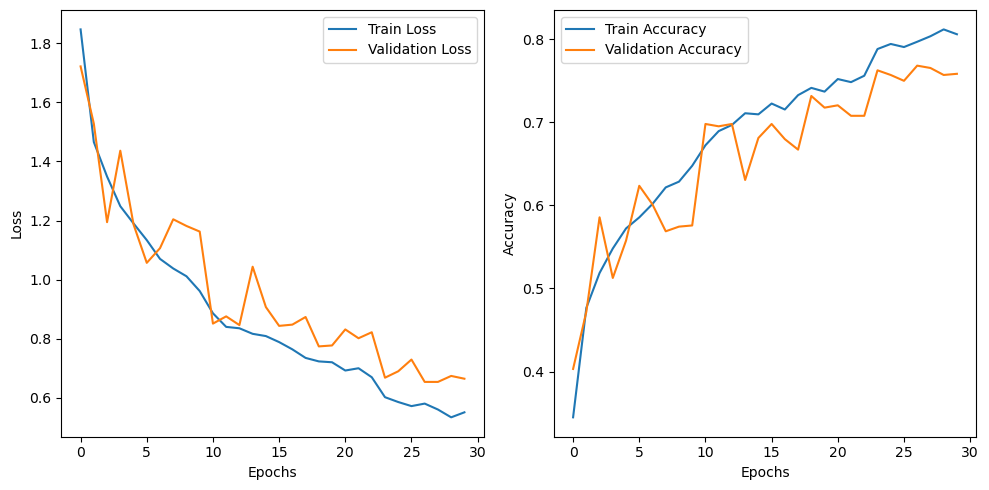

In [53]:
history, trained_model = Train(device, model_Adm, epochs=30,  optimizer=optimizer, scheduler=scheduler, name=name, save_dir="models")

train_hist["adam"] = history

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19352\3301976.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("models/best_model_Adam.pth", map_locati


 Test Accuracy: 77.03%

 Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.80      0.81      0.80        63
      Food Organics       0.78      0.93      0.85        73
              Glass       0.88      0.71      0.79        59
              Metal       0.72      0.88      0.79       129
Miscellaneous Trash       0.69      0.55      0.61        78
              Paper       0.90      0.77      0.83        71
            Plastic       0.70      0.76      0.73       133
      Textile Trash       0.71      0.42      0.53        40
         Vegetation       0.91      0.87      0.89        68

           accuracy                           0.77       714
          macro avg       0.79      0.75      0.76       714
       weighted avg       0.77      0.77      0.77       714


 Confusion Matrix:
[[ 51   3   0   1   3   1   4   0   0]
 [  0  68   1   0   0   0   3   0   1]
 [  3   0  42   7   2   0   5   0   0]
 [  1   0   2 114 

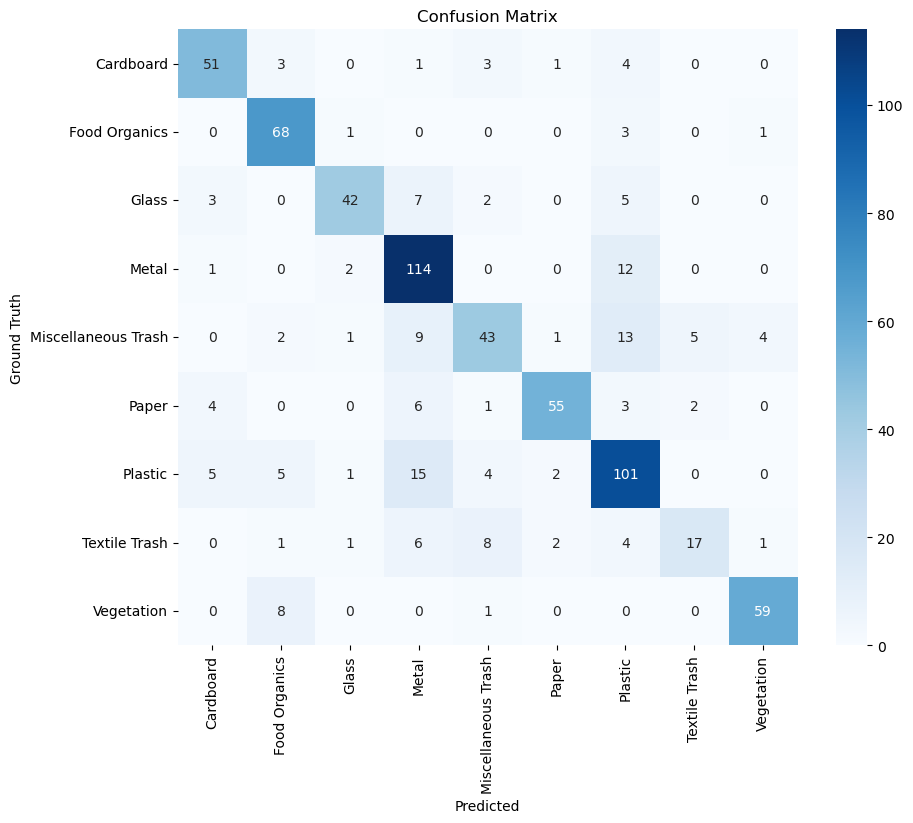

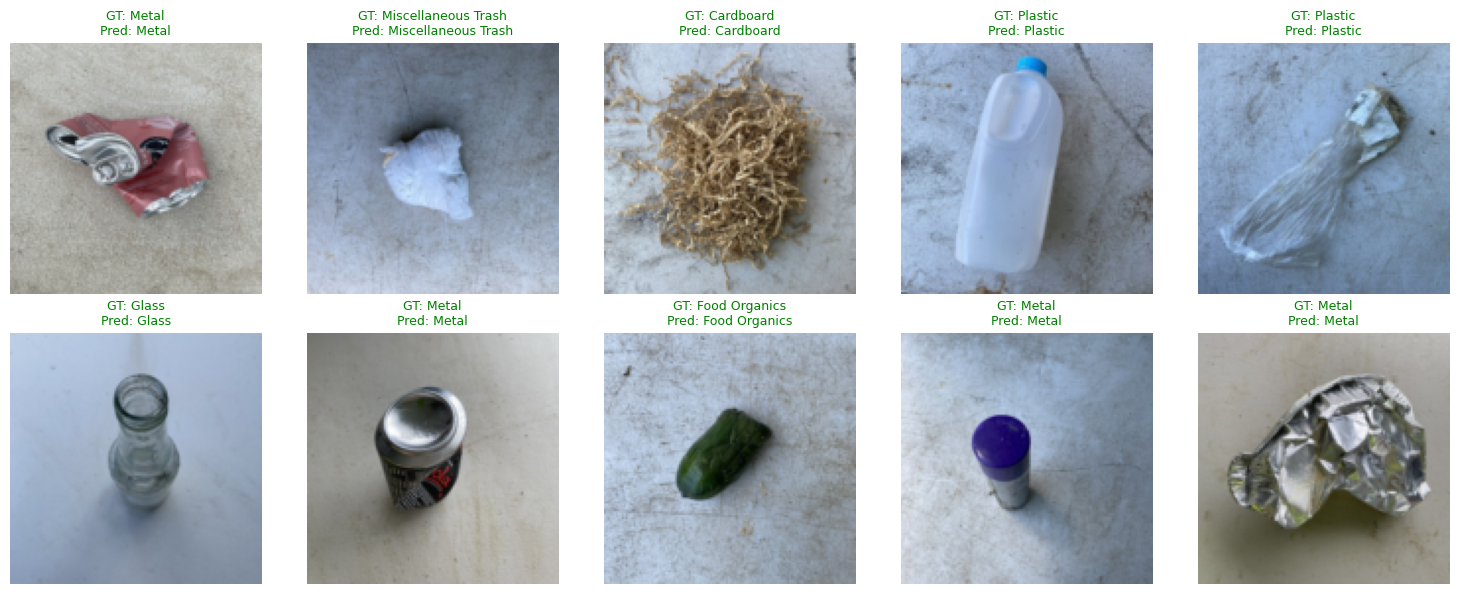

In [32]:
# Instantiate  CNN
class_names = dataset.classes 

num_classes = len(class_names)  
model = CNN_model(in_channel=3, num_classes=num_classes)
model = model.to(device)

# Load the trained weights
checkpoint = torch.load("models/best_model_Adam.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Evaluate
evaluate_model(model, test_loader, class_names, num_samples_to_show=10)


## CNN Model - SGD

In [58]:
model_SGD = CNN_model(in_channel=3, num_classes=num_classes).to(device)


# Standard SGD configuration
optimizer = optim.SGD(
        model_SGD.parameters(),
        lr=0.0005,                # Initial learning rate
        weight_decay=1e-4       # L2 regularization to prevent overfitting
    )
    

# Learning rate scheduler (reduce LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',
        factor=0.5,             # Multiply LR by 0.5 when plateauing
        patience=3              # Wait 4 epochs before reducing LR
    )

name = "SGD"

Epoch 1/30 [Train]


100%|██████████| 118/118 [00:27<00:00,  4.35it/s]


Epoch 1/30 [Val]


100%|██████████| 23/23 [00:04<00:00,  5.36it/s]


Saved new best model with validation loss: 2.1925
Epoch: 1/30, Time: 31.45s, Train Loss: 2.2088, Train Acc: 0.0925, Val Loss: 2.1925, Val Acc: 0.0871, LR: 0.000500
Epoch 2/30 [Train]


...

Saved new best model with validation loss: 2.0158
Epoch: 29/30, Time: 94.52s, Train Loss: 2.0529, Train Acc: 0.2991, Val Loss: 2.0158, Val Acc: 0.3188, LR: 0.000500
Epoch 30/30 [Train]


100%|██████████| 118/118 [01:17<00:00,  1.51it/s]


Epoch 30/30 [Val]


100%|██████████| 23/23 [00:14<00:00,  1.57it/s]


Saved new best model with validation loss: 2.0040
Epoch: 30/30, Time: 92.63s, Train Loss: 2.0429, Train Acc: 0.2941, Val Loss: 2.0040, Val Acc: 0.3244, LR: 0.000500
Training completed. Best validation loss: 2.0040
Best model saved to models\best_model_SGD.pth
Last model saved to models\last_model_SGD.pth


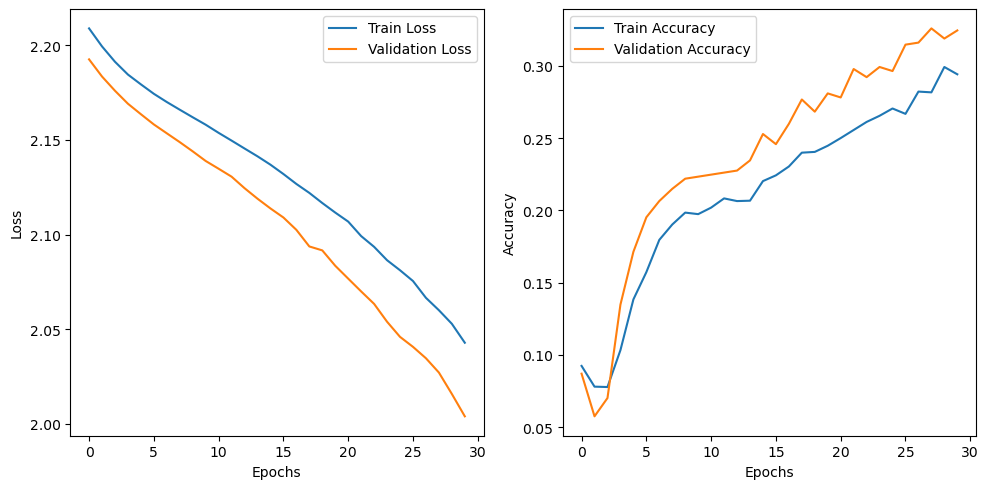

In [59]:
history, trained_model = Train(device, model_SGD, epochs=30,  optimizer=optimizer, scheduler=scheduler, name=name, save_dir="models")
train_hist["sgd"] = history

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19352\3486567305.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("models/best_model_SGD.pth", map_loca


 Test Accuracy: 34.45%

 Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.50      0.03      0.06        63
      Food Organics       0.33      0.37      0.35        73
              Glass       0.41      0.44      0.42        59
              Metal       0.37      0.74      0.49       129
Miscellaneous Trash       0.00      0.00      0.00        78
              Paper       0.00      0.00      0.00        71
            Plastic       0.32      0.71      0.44       133
      Textile Trash       0.00      0.00      0.00        40
         Vegetation       0.00      0.00      0.00        68

           accuracy                           0.34       714
          macro avg       0.21      0.26      0.20       714
       weighted avg       0.24      0.34      0.25       714


 Confusion Matrix:
[[ 2  4 10  9  0  0 38  0  0]
 [ 0 27  8 10  0  0 28  0  0]
 [ 0  0 26  7  0  0 26  0  0]
 [ 0  0  7 96  0  0 26  0  0]
 [ 0  7  5 44  

c:\Users\ASUS\miniconda3\envs\torch_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\miniconda3\envs\torch_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\miniconda3\envs\torch_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

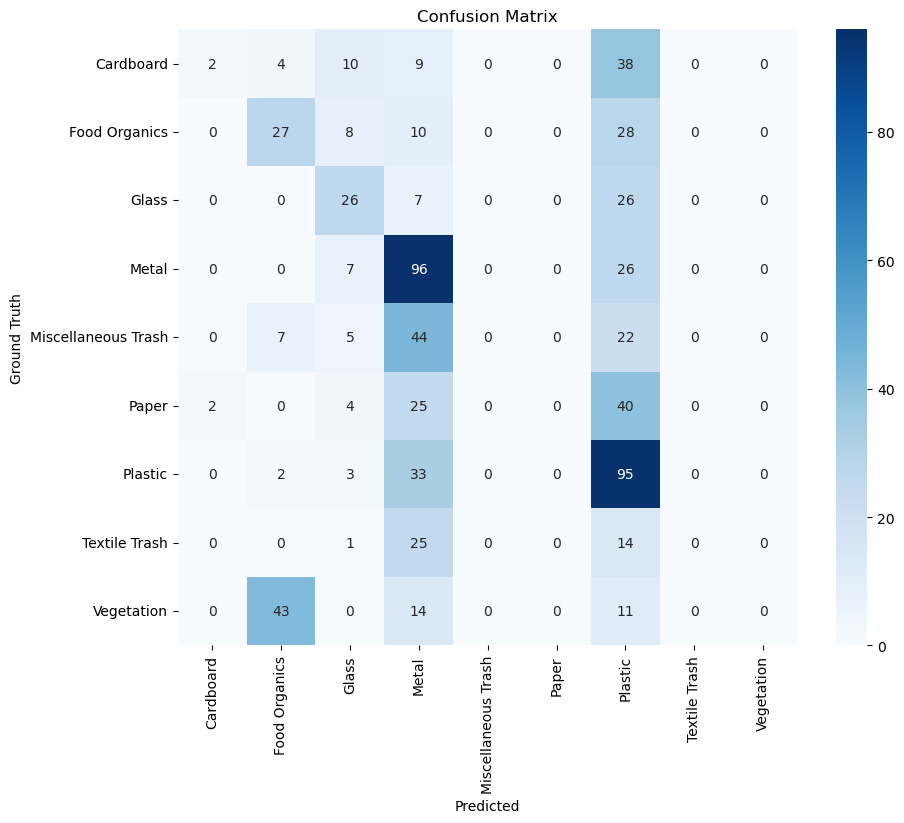

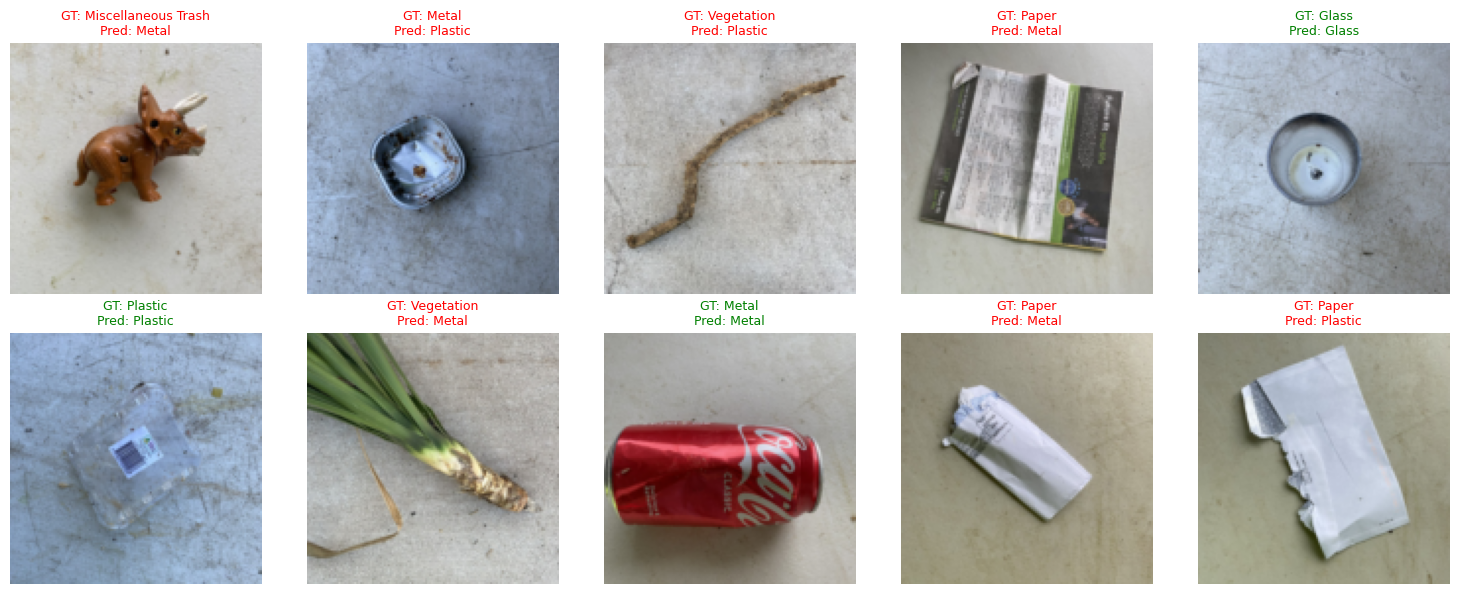

In [40]:
# Instantiate  CNN
class_names = dataset.classes 

num_classes = len(class_names) 
model = CNN_model(in_channel=3, num_classes=num_classes)
model = model.to(device)

# Load the trained weights
checkpoint = torch.load("models/best_model_SGD.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Evaluate
evaluate_model(model, test_loader, class_names, num_samples_to_show=10)


## CNN Model - SGD with Momentum

In [35]:
model_SGDM = CNN_model(in_channel=3,num_classes=num_classes).to(device)


optimizer = optim.SGD(
        model_SGDM.parameters(),
        lr=0.01,                # Initial learning rate
        momentum=0.9,           # Momentum factor (0.9 is a common choice)
        nesterov=True,          # Using Nesterov accelerated gradient
        weight_decay=1e-4       # L2 regularization to prevent overfitting
    )
    
    # Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',
        factor=0.3,             
        patience=3,             # Wait 5 epochs before reducing LR
    )

name = "SGDM"

Epoch 1/20 [Train]


100%|██████████| 118/118 [00:56<00:00,  2.09it/s]


Epoch 1/20 [Val]


100%|██████████| 23/23 [00:10<00:00,  2.19it/s]


Saved new best model with validation loss: 2.7894
Epoch: 1/20, Time: 66.92s, Train Loss: 1.9171, Train Acc: 0.2912, Val Loss: 2.7894, Val Acc: 0.1236, LR: 0.010000
Epoch 2/20 [Train]


...

Epoch: 19/20, Time: 107.20s, Train Loss: 0.7165, Train Acc: 0.7372, Val Loss: 1.1378, Val Acc: 0.6264, LR: 0.003000
Epoch 20/20 [Train]


100%|██████████| 118/118 [01:39<00:00,  1.18it/s]


Epoch 20/20 [Val]


100%|██████████| 23/23 [00:16<00:00,  1.41it/s]


Saved new best model with validation loss: 0.7645
Epoch: 20/20, Time: 116.30s, Train Loss: 0.7089, Train Acc: 0.7434, Val Loss: 0.7645, Val Acc: 0.7219, LR: 0.003000
Training completed. Best validation loss: 0.7645
Best model saved to models\best_model_SGDM.pth
Last model saved to models\last_model_SGDM.pth


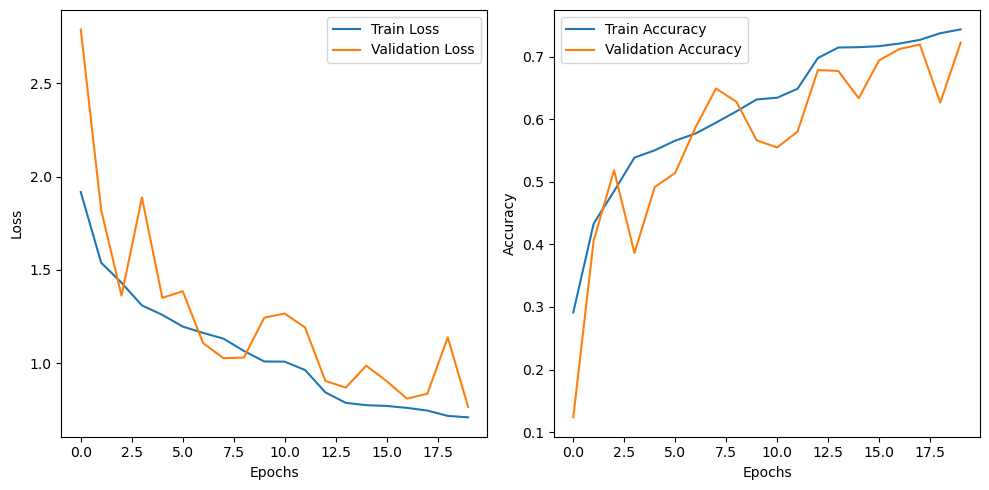

In [36]:
history, trained_model = Train(device, model_SGDM, epochs=20,  optimizer=optimizer, scheduler=scheduler, name=name, save_dir="models")
train_hist["sgdm"] = history


# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19352\2912115209.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("models/best_model_SGDM.pth", map_loc


 Test Accuracy: 74.23%

 Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.68      0.78      0.73        63
      Food Organics       0.82      0.77      0.79        73
              Glass       0.90      0.73      0.80        59
              Metal       0.79      0.80      0.80       129
Miscellaneous Trash       0.53      0.42      0.47        78
              Paper       0.87      0.68      0.76        71
            Plastic       0.72      0.78      0.75       133
      Textile Trash       0.54      0.70      0.61        40
         Vegetation       0.80      0.97      0.88        68

           accuracy                           0.74       714
          macro avg       0.74      0.74      0.73       714
       weighted avg       0.75      0.74      0.74       714


 Confusion Matrix:
[[ 49   4   1   0   1   1   5   2   0]
 [  0  56   0   1   1   0   7   0   8]
 [  5   1  43   4   3   0   3   0   0]
 [  3   0   1 103 

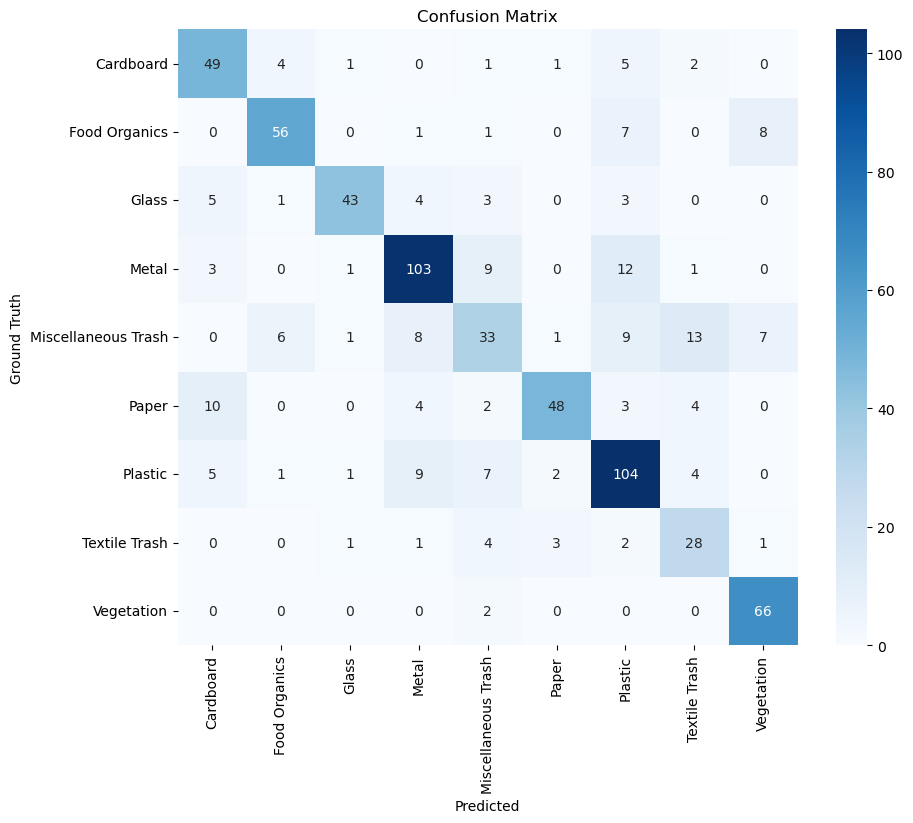

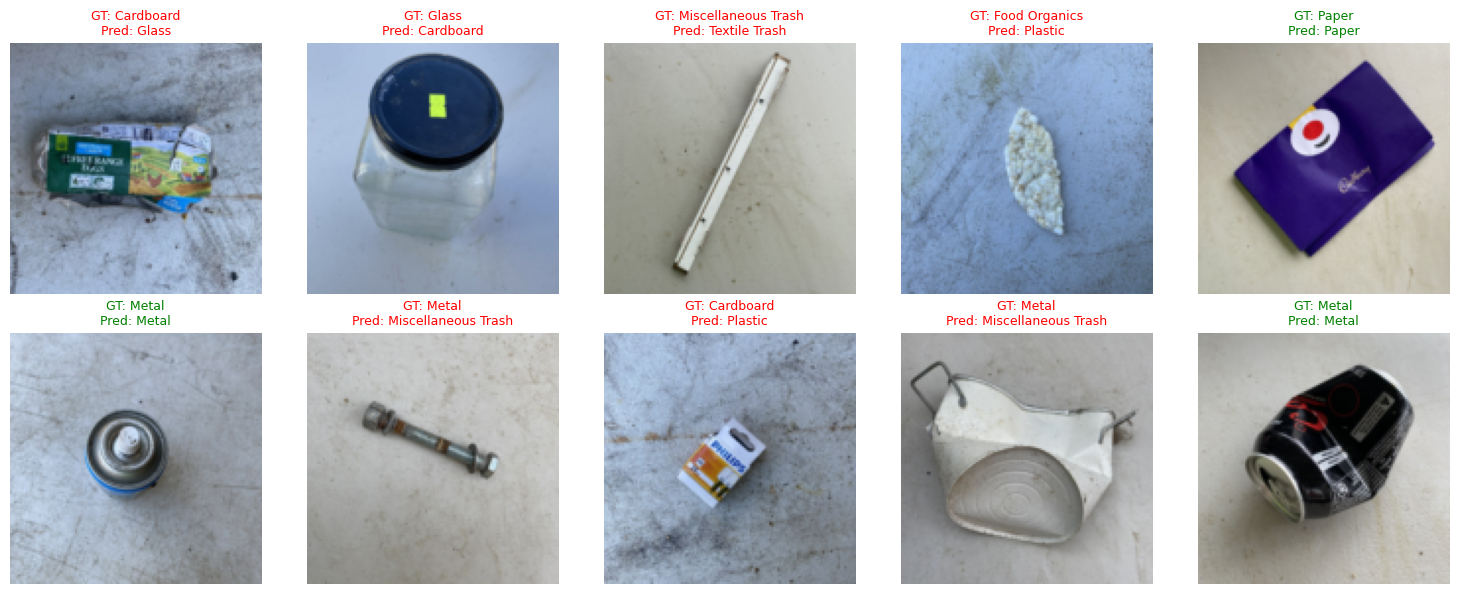

In [41]:
# Instantiate  CNN
class_names = dataset.classes 

num_classes = len(class_names) 
model = CNN_model(in_channel=3, num_classes=num_classes)
model = model.to(device)

# Load the trained weights
checkpoint = torch.load("models/best_model_SGDM.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Evaluate
evaluate_model(model, test_loader, class_names, num_samples_to_show=10)


## AlexNet Model

In [16]:

model_ft = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

# Freeze convolutional layers
for param in model_ft.features.parameters():
    param.requires_grad = False

# Replace classifier head
num_ftrs = model_ft.classifier[6].in_features
model_ft.classifier[6] = nn.Sequential(
    nn.Dropout(0.5),                 # add dropout 
    nn.Linear(num_ftrs, 256),        # bottleneck
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),                 # dropout again
    nn.Linear(256, num_classes)      # final layer
)

model_ft = model_ft.to(device)


optimizer_ft = optim.Adam(
    model_ft.classifier[6].parameters(),
    lr=1e-4,                         # reduce LR (5e-4 is aggressive)
    weight_decay=1e-4                # L2 regularization
)

scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=5, gamma=0.1)
name = "AlexNet_FT"


Epoch 1/20 [Train]


100%|██████████| 118/118 [01:00<00:00,  1.95it/s]


Epoch 1/20 [Val]


100%|██████████| 23/23 [00:12<00:00,  1.86it/s]


Saved new best model with validation loss: 1.0561
Epoch: 1/20, Time: 74.54s, Train Loss: 1.5795, Train Acc: 0.4540, Val Loss: 1.0561, Val Acc: 0.6573, LR: 0.000100
Epoch 2/20 [Train]


...

Epoch: 19/20, Time: 124.60s, Train Loss: 0.4898, Train Acc: 0.8228, Val Loss: 0.6886, Val Acc: 0.7542, LR: 0.000100
Epoch 20/20 [Train]


100%|██████████| 118/118 [01:45<00:00,  1.12it/s]


Epoch 20/20 [Val]


100%|██████████| 23/23 [00:19<00:00,  1.19it/s]


Saved new best model with validation loss: 0.6796
Epoch: 20/20, Time: 126.47s, Train Loss: 0.4720, Train Acc: 0.8313, Val Loss: 0.6796, Val Acc: 0.7654, LR: 0.000100
Training completed. Best validation loss: 0.6796
Best model saved to models\best_model_AlexNet_FT.pth
Last model saved to models\last_model_AlexNet_FT.pth


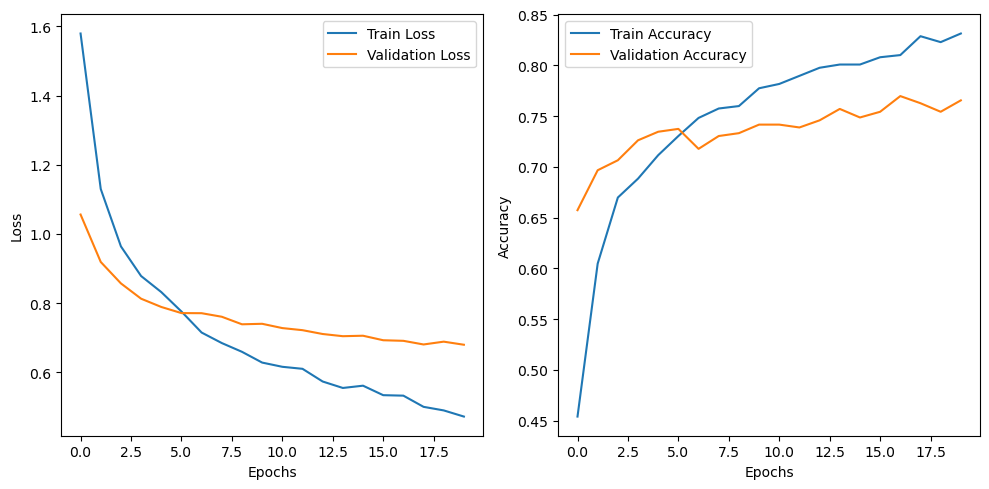

In [17]:
history, trained_model = Train(device, model_ft, epochs=20,  optimizer=optimizer_ft, scheduler=scheduler, name=name, save_dir="models")
train_hist["AlexNet"] = history

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
from torchvision import models
import torch.nn as nn



# Load AlexNet skeleton
model = models.alexnet(weights=None)

# Freeze conv layers (optional but safe)
for param in model.features.parameters():
    param.requires_grad = False

# Rebuild classification head EXACTLY as training
num_classes = len(dataset.classes)
model.classifier[6] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.classifier[6].in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)

# Load checkpoint
checkpoint = torch.load("models/best_model_AlexNet_FT.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

model = model.to(device)
model.eval()

print("Model loaded successfully ")


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19352\1426605354.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("models/best_model_AlexNet_FT.pth", 

Model loaded successfully 



 Test Accuracy: 78.57%

 Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.77      0.79      0.78        63
      Food Organics       0.84      0.79      0.82        73
              Glass       0.76      0.76      0.76        59
              Metal       0.76      0.87      0.81       129
Miscellaneous Trash       0.76      0.64      0.69        78
              Paper       0.87      0.75      0.80        71
            Plastic       0.76      0.77      0.77       133
      Textile Trash       0.68      0.70      0.69        40
         Vegetation       0.87      0.91      0.89        68

           accuracy                           0.79       714
          macro avg       0.79      0.78      0.78       714
       weighted avg       0.79      0.79      0.78       714


 Confusion Matrix:
[[ 50   0   1   0   2   3   6   1   0]
 [  0  58   0   0   2   0   5   1   7]
 [  0   0  45   5   1   1   7   0   0]
 [  1   1   4 112 

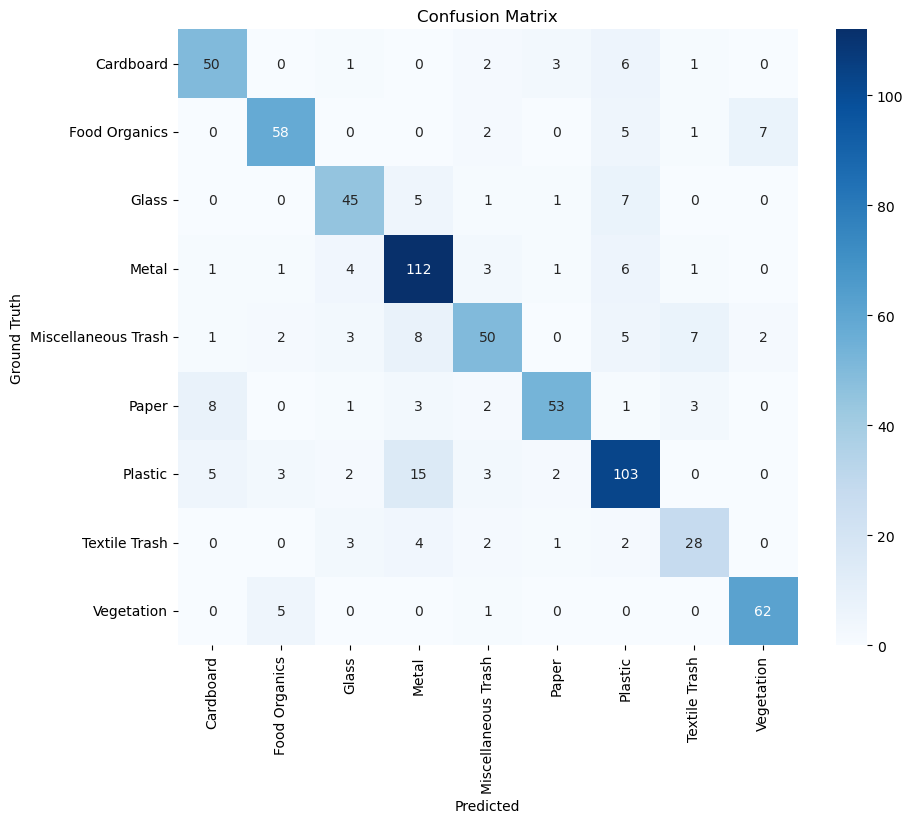

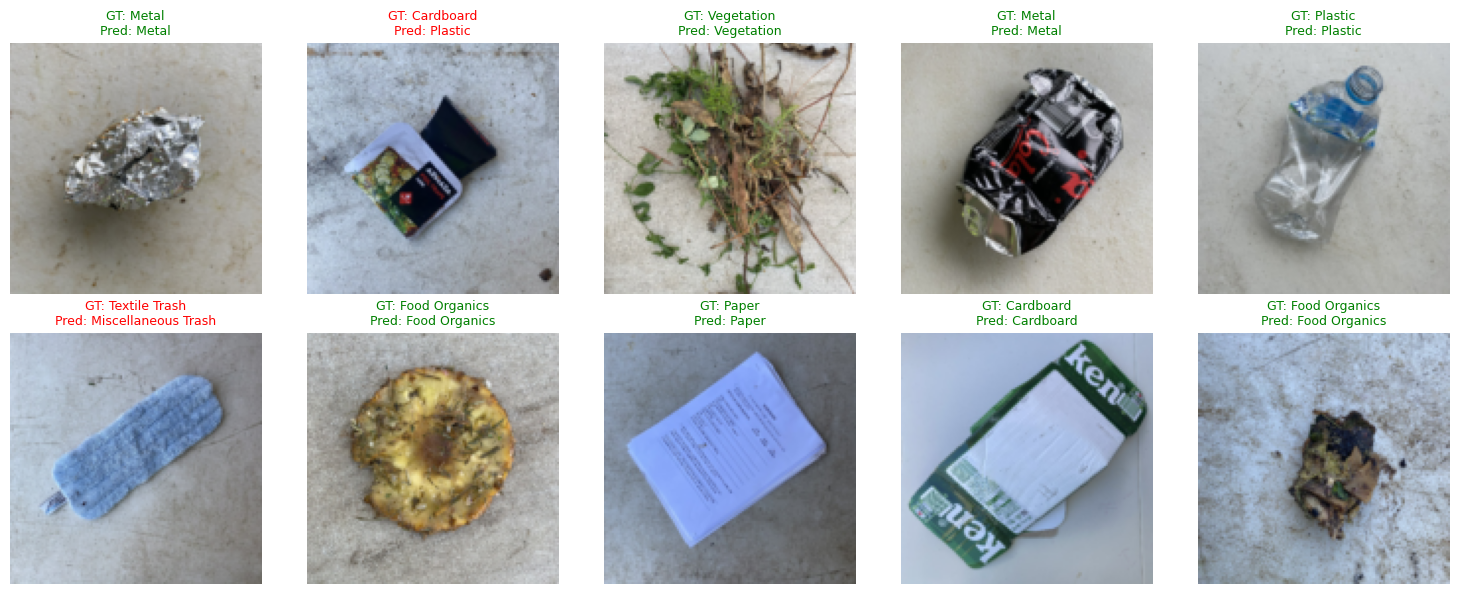

In [28]:
evaluate_model(model, test_loader, classes=dataset.classes)


In [54]:
import json

def _json_default(o):
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.floating, np.integer)):
        return float(o)
    if isinstance(o, torch.Tensor):
        return o.detach().cpu().tolist()
    raise TypeError(f"Type {type(o)} not JSON serializable")

with open("models/training_histories.json", "w") as f:
    json.dump(train_hist, f, indent=2, default=_json_default)

In [55]:
!zip -r models.zip /kaggle/working/models

  adding: kaggle/working/models/ (stored 0%)
  adding: kaggle/working/models/best_model_Adam.pth (deflated 8%)
  adding: kaggle/working/models/last_model_SGDM.pth (deflated 7%)
  adding: kaggle/working/models/best_model_SGDM.pth (deflated 7%)
  adding: kaggle/working/models/last_model_SGD.pth (deflated 8%)
  adding: kaggle/working/models/best_model_Resnet_50.pth (deflated 7%)
  adding: kaggle/working/models/last_model_Adam.pth (deflated 8%)
  adding: kaggle/working/models/best_model_SGD.pth (deflated 8%)
  adding: kaggle/working/models/best_model_AdamW.pth (deflated 8%)
  adding: kaggle/working/models/training_histories.json (deflated 69%)
  adding: kaggle/working/models/last_model_Resnet_50.pth (deflated 7%)
  adding: kaggle/working/models/last_model_AdamW.pth (deflated 8%)


## Comparision Plot for CNN model

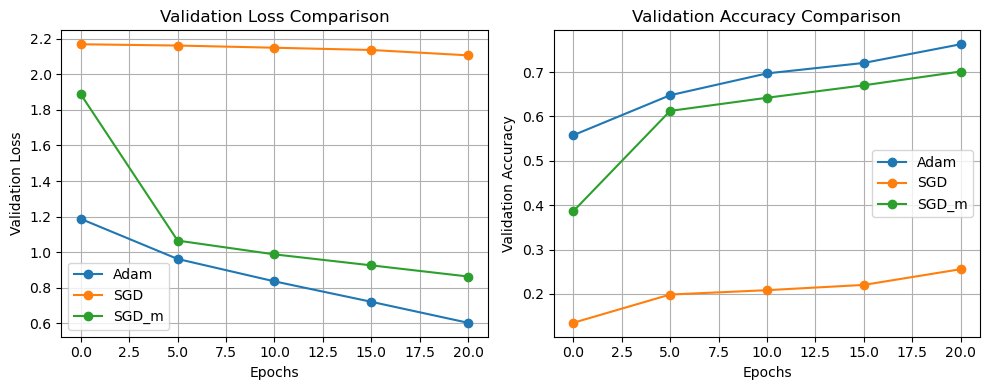

In [45]:
import matplotlib.pyplot as plt

# Sampled epochs
epochs = [0, 5, 10, 15, 20]

# Validation Loss (approximate values at those epochs from your data)
val_loss_adam = [1.1871, 0.9617, 0.8357, 0.7208, 0.6027]
val_loss_sgd = [2.1691, 2.1619, 2.1496, 2.1369, 2.1068]
val_loss_sgd_m = [1.8878, 1.0650, 0.9875, 0.9257, 0.8630]

# Validation Accuracy
val_acc_adam = [0.5576, 0.6477, 0.6969, 0.7205, 0.7626]
val_acc_sgd = [0.1348, 0.1985, 0.2083, 0.2202, 0.2556]
val_acc_sgd_m = [0.3862, 0.6124, 0.6420, 0.6701, 0.7012]

# Plotting
plt.figure(figsize=(10,4))

# Validation Loss
plt.subplot(1,2,1)
plt.plot(epochs, val_loss_adam, marker='o', label='Adam')
plt.plot(epochs, val_loss_sgd, marker='o', label='SGD')
plt.plot(epochs, val_loss_sgd_m, marker='o', label='SGD_m')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.grid(True)

# Validation Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, val_acc_adam, marker='o', label='Adam')
plt.plot(epochs, val_acc_sgd, marker='o', label='SGD')
plt.plot(epochs, val_acc_sgd_m, marker='o', label='SGD_m')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
